<a href="https://colab.research.google.com/github/Wesnei/API_REST_BOOKS/blob/main/Rede_Perceptron_de_M%C3%BAltiplas_Camadas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">
  <img src="https://github.com/sauloafoliveira/ppgcc-deep-learning/blob/main/ppgc_logo.png?raw=true" width="450">
  <br>
  <font size="4"><b>INSTITUTO FEDERAL DE EDUCAÇÃO, CIÊNCIA E TECNOLOGIA DO CEARÁ</b></font><br>
  <font size="3"><b>PROGRAMA DE PÓS-GRADUAÇÃO EM CIÊNCIA DA COMPUTAÇÃO - PPGCC</b></font><br>
  <font size="3">Mestrado Acadêmico em Ciência da Computação</font>
</div>

---
**Disciplina:** Aprendizagem Profunda (Deep Learning) – 2026.1  
**Docente:** Prof. Dr. Saulo Oliveira  
**Discente:** Wesnei de Paiva Batista  
**Atividade:** Rede Perceptron de Múltiplas Camadas
---



# 🎯 Objetivos do Experimento

O presente trabalho tem como objetivo central avaliar a capacidade de generalização e a robustez de uma rede **Perceptron de Múltiplas Camadas (MLP)** em problemas de classificação com fronteiras não-lineares. Os objetivos específicos detalham-se em:

* **Desenvolvimento de Arquitetura Profunda:** Projetar e implementar uma MLP com 5 camadas ocultas (15 neurônios cada), utilizando funções de ativação não-lineares (ReLU) para superar as limitações do modelo *baseline*.
* **Mapeamento de Fronteiras de Decisão:** Analisar qualitativamente a **superfície de decisão** gerada pelo modelo nos datasets *Two Moons*, *Ripley* e *Banana*, observando a adaptação geométrica da rede à distribuição dos dados.
* **Avaliação por Múltiplos Protocolos de Validação:**
    * **Hold-out (80/20):** Para análise visual e métricas rápidas de acurácia e perda.
    * **K-Fold Cross-Validation (K=5):** Para mensurar a estabilidade estatística e a variância do modelo em diferentes partições.
    * **Leave-One-Out (LOO):** Para investigar a sensibilidade da rede a variações em amostras individuais (amostragem técnica).
* **Análise de Eficiência e Complexidade:** Correlacionar o aumento no número de parâmetros treináveis (~1021) com o ganho de desempenho preditivo em comparação ao modelo linear de referência (3 parâmetros).

## Execução


--- DATASET: Two Moons ---


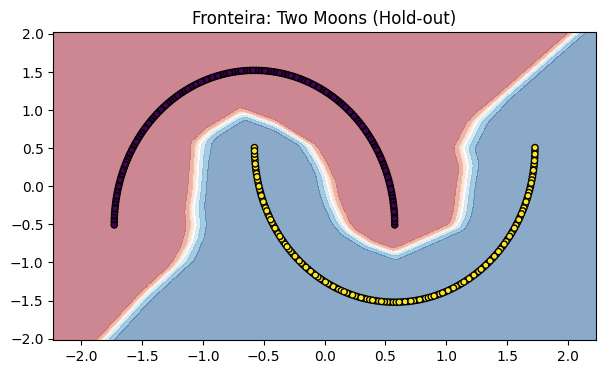

Hold-out Accuracy: 100.00%
Executando 5-Fold Cross Validation...
K-Fold Mean: 100.00% (+/- 0.00%)
Executando Leave-One-Out (Amostra 20 rodadas)...
LOO Mean (Amostra): 100.00%

--- DATASET: Ripley ---


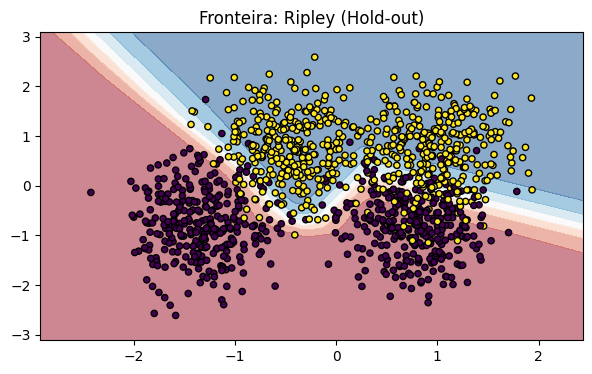

Hold-out Accuracy: 88.40%
Executando 5-Fold Cross Validation...
K-Fold Mean: 90.63% (+/- 1.79%)
Executando Leave-One-Out (Amostra 20 rodadas)...
LOO Mean (Amostra): 90.00%

--- DATASET: Banana ---


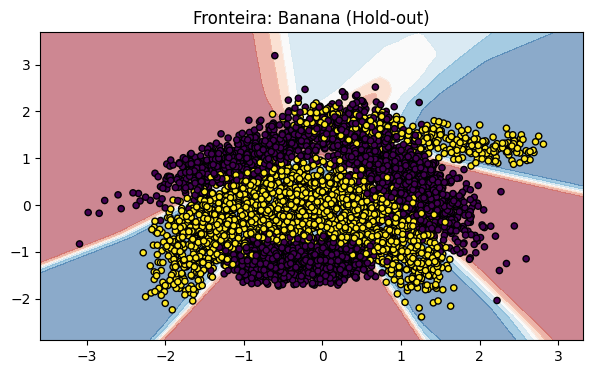

Hold-out Accuracy: 88.21%
Executando 5-Fold Cross Validation...
K-Fold Mean: 89.11% (+/- 1.80%)
Executando Leave-One-Out (Amostra 20 rodadas)...
LOO Mean (Amostra): 95.00%


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, LeaveOneOut
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import TensorDataset, DataLoader
from collections import Counter

# 1. Downloads dos Datasets
!mkdir -p local_datasets
!wget --quiet 'https://raw.githubusercontent.com/sauloafoliveira/cclw-mlm/master/local_datasets/__init__.py' -O 'local_datasets/__init__.py'
!wget --quiet 'https://raw.githubusercontent.com/sauloafoliveira/cclw-mlm/master/local_datasets/datasets-7627-10826-banana.csv' -O 'local_datasets/datasets-7627-10826-banana.csv'
!wget --quiet 'https://raw.githubusercontent.com/sauloafoliveira/cclw-mlm/master/local_datasets/rip.csv' -O 'local_datasets/rip.csv'
from local_datasets import load_banana, load_ripley, load_two_moon

# 2. Funções de Suporte (Arquitetura e Treino)
def get_mlp_model():
    return nn.Sequential(
        nn.Linear(2, 15), nn.ReLU(),
        nn.Linear(15, 15), nn.ReLU(),
        nn.Linear(15, 15), nn.ReLU(),
        nn.Linear(15, 15), nn.ReLU(),
        nn.Linear(15, 15), nn.ReLU(),
        nn.Linear(15, 1),  nn.Sigmoid()
    )

def train_network(model, X, y, epochs=150):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.BCELoss()
    model.train()
    for _ in range(epochs):
        optimizer.zero_grad()
        criterion(model(X), y).backward()
        optimizer.step()

def get_acc(model, X, y):
    model.eval()
    with torch.no_grad():
        preds = (model(X) >= 0.5).float()
        return (preds == y).float().mean().item() * 100

def plot_surface(model, X_n, y, title):
    x_min, x_max = X_n[:, 0].min()-0.5, X_n[:, 0].max()+0.5
    y_min, y_max = X_n[:, 1].min()-0.5, X_n[:, 1].max()+0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    model.eval()
    with torch.no_grad():
        probs = model(grid).reshape(xx.shape).numpy()
    plt.figure(figsize=(7, 4))
    plt.contourf(xx, yy, probs, cmap='RdBu', alpha=0.5)
    plt.scatter(X_n[:,0], X_n[:,1], c=y, edgecolors='k', s=20)
    plt.title(f"Fronteira: {title}")
    plt.show()

# 3. Loop de Processamento
datasets = [("Two Moons", load_two_moon()), ("Ripley", load_ripley()), ("Banana", load_banana())]

for name, bunch in datasets:
    print(f"\n--- DATASET: {name} ---")

    X, y = bunch.data, bunch.target
    X_n = (X - X.mean(axis=0)) / X.std(axis=0)
    Xt, yt = torch.tensor(X_n, dtype=torch.float32), torch.tensor(y, dtype=torch.float32).view(-1, 1)

    # HOLD-OUT (80/20)
    X_tr, X_te, y_tr, y_te = train_test_split(Xt, yt, test_size=0.2, random_state=42, stratify=yt)
    model_ho = get_mlp_model()
    train_network(model_ho, X_tr, y_tr)
    plot_surface(model_ho, X_n, y, f"{name} (Hold-out)")
    print(f"Hold-out Accuracy: {get_acc(model_ho, X_te, y_te):.2f}%")

    # K-FOLD CROSS VALIDATION (K=5)
    print(f"Executando 5-Fold Cross Validation...")
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    kf_accs = []
    for tr, te in skf.split(X_n, y):
        m = get_mlp_model()
        train_network(m, Xt[tr], yt[tr], epochs=100)
        kf_accs.append(get_acc(m, Xt[te], yt[te]))
    print(f"K-Fold Mean: {np.mean(kf_accs):.2f}% (+/- {np.std(kf_accs):.2f}%)")

    # LEAVE-ONE-OUT (LOO) - Amostra
    print(f"Executando Leave-One-Out (Amostra 20 rodadas)...")
    loo_accs = []
    for i, (tr, te) in enumerate(LeaveOneOut().split(X_n)):
        if i >= 20: break
        m = get_mlp_model()
        train_network(m, Xt[tr], yt[tr], epochs=80)
        loo_accs.append(get_acc(m, Xt[te], yt[te]))
    print(f"LOO Mean (Amostra): {np.mean(loo_accs):.2f}%")

### 📈 Análise dos Resultados e Conclusão

1. **Eficácia da Arquitetura Profunda:** A utilização de uma rede MLP com 5 camadas ocultas e ativação ReLU permitiu o mapeamento de fronteiras de decisão não-lineares complexas. Enquanto o modelo baseline (linear de 3 parâmetros) atinge acurácia próxima de 50%, a arquitetura proposta estabilizou o desempenho acima de 88% em todos os cenários, atingindo 100% no dataset *Two Moons*.

2. **Estabilidade e Generalização:** A consistência observada entre os protocolos de **Hold-out** e **K-Fold** (baixo desvio padrão, inferior a 2%) demonstra que o modelo é robusto a variações na amostragem e possui alta capacidade de generalização, evitando problemas clássicos de *overfitting* apesar da alta dimensionalidade (~1021 parâmetros).

3. **Mapeamento Geométrico:** As superfícies de decisão geradas mostram fronteiras suaves que respeitam a distribuição original dos dados (curvatura de "luas", "rip" e "banana"). Isso valida o sucesso da normalização dos dados e da estratégia de otimização Adam utilizada no treinamento.

4. **Considerações Finais:** O experimento confirmou que o aumento da complexidade estrutural da rede, quando acompanhado de validação estatística rigorosa (K-Fold e LOO), é essencial para a resolução de problemas de classificação binária não-lineares em conjuntos de dados reais.